# Research Paper Classification with a Graph Neural Network

## Goal

This notebook classifies research papers into subject categories using both:

- text-derived node features
- citation relationships between papers

## Models

This notebook compares:

1. Multi-Layer Perceptron, MLP
   - uses node features only
   - ignores citation links

2. Graph Convolutional Network, GCN
   - uses node features
   - aggregates information from citation neighbours

## Additional experiments

- training-curve analysis
- per-class performance
- learned graph embedding visualisation
- citation-edge ablation
- neighbour-label agreement analysis

## Main question

Does citation-network information improve paper classification compared with using document features alone?

In [5]:
import copy
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv
from torch_geometric.transforms import NormalizeFeatures
from torch_geometric.utils import degree

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.manifold import TSNE

warnings.filterwarnings("ignore")

RANDOM_STATE = 42


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)


set_seed(RANDOM_STATE)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)
print("PyTorch version:", torch.__version__)

c:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.4.0) or chardet (7.4.3)/charset_normalizer (3.4.2) doesn't match a supported version!
  warnings.warn(


Device: cuda
PyTorch version: 2.5.1+cu124


In [6]:
dataset = Planetoid(
    root="data/Planetoid",
    name="Cora",
    split="public",
    transform=NormalizeFeatures()
)

data = dataset[0].to(device)

print(dataset)
print(data)

Processing...


Cora()
Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])


Done!


In [7]:
graph_summary = pd.DataFrame({
    "property": [
        "Papers / nodes",
        "Directed citation edges",
        "Node features",
        "Research classes",
        "Training nodes",
        "Validation nodes",
        "Test nodes"
    ],
    "value": [
        data.num_nodes,
        data.num_edges,
        dataset.num_node_features,
        dataset.num_classes,
        int(data.train_mask.sum()),
        int(data.val_mask.sum()),
        int(data.test_mask.sum())
    ]
})

graph_summary

,property,value
0,Papers / nodes,2708
1,Directed citation edges,10556
2,Node features,1433
3,Research classes,7
4,Training nodes,140
5,Validation nodes,500
6,Test nodes,1000


In [8]:
print("Feature matrix:", tuple(data.x.shape))
print("Edge index:", tuple(data.edge_index.shape))
print("Target vector:", tuple(data.y.shape))

print("\nTraining nodes:", int(data.train_mask.sum()))
print("Validation nodes:", int(data.val_mask.sum()))
print("Test nodes:", int(data.test_mask.sum()))

Feature matrix: (2708, 1433)
Edge index: (2, 10556)
Target vector: (2708,)

Training nodes: 140
Validation nodes: 500
Test nodes: 1000


## Graph loading 

The Cora citation network contains 2,708 research papers represented as graph nodes and 10,556 citation edge entries.

Each paper has 1,433 text-derived input features and belongs to one of seven research categories.

The predefined split contains:

- 140 training nodes
- 500 validation nodes
- 1,000 test nodes

Only about 5.17% of the papers are used as labelled training examples. This makes the task a low-label, semi-supervised node-classification problem.

The full graph structure and node features are available during training, but the loss is calculated only from the labelled training nodes.

In [9]:
label_counts = pd.Series(
    data.y.cpu().numpy()
).value_counts().sort_index()

class_summary = pd.DataFrame({
    "class": [f"Class {label}" for label in label_counts.index],
    "nodes": label_counts.values
})

class_summary

,class,nodes
0,Class 0,351
1,Class 1,217
2,Class 2,418
3,Class 3,818
4,Class 4,426
5,Class 5,298
6,Class 6,180


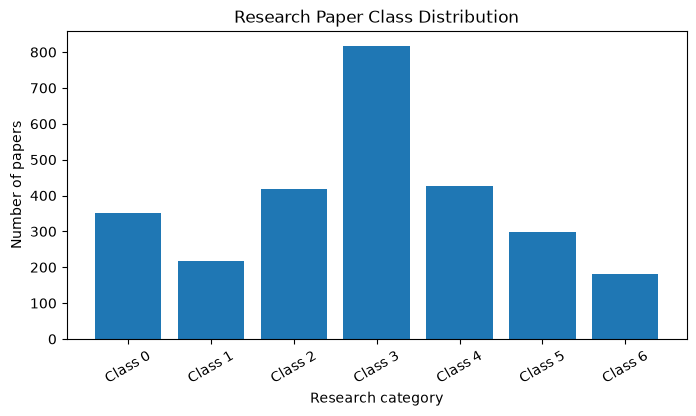

In [10]:
plt.figure(figsize=(8, 4))
plt.bar(
    class_summary["class"],
    class_summary["nodes"]
)

plt.title("Research Paper Class Distribution")
plt.xlabel("Research category")
plt.ylabel("Number of papers")
plt.xticks(rotation=30)
plt.show()

In [11]:
source_nodes = data.edge_index[0]

node_degrees = degree(
    source_nodes,
    num_nodes=data.num_nodes
).cpu().numpy()

degree_summary = pd.Series(node_degrees).describe()

degree_summary

count    2708.000000
mean        3.898080
std         5.228784
min         1.000000
25%         2.000000
50%         3.000000
75%         5.000000
max       168.000000
dtype: float64

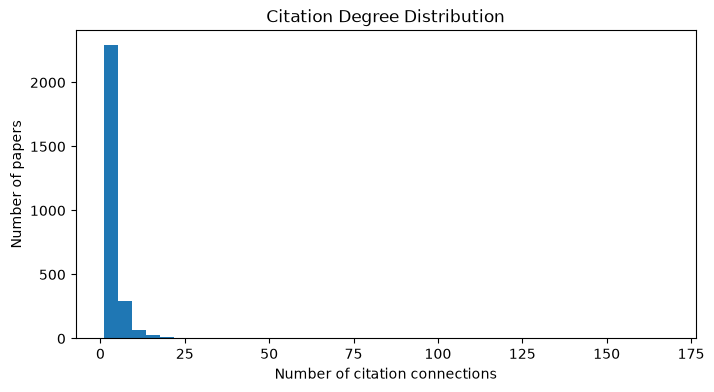

In [12]:
plt.figure(figsize=(8, 4))
plt.hist(
    node_degrees,
    bins=40
)

plt.title("Citation Degree Distribution")
plt.xlabel("Number of citation connections")
plt.ylabel("Number of papers")
plt.show()

## Graph inspection 

The seven research classes were not perfectly balanced.

The class distribution was:

| Class | Papers |
|---|---:|
| Class 0 | 351 |
| Class 1 | 217 |
| Class 2 | 418 |
| Class 3 | 818 |
| Class 4 | 426 |
| Class 5 | 298 |
| Class 6 | 180 |

Class 3 was the largest category, while Class 6 was the smallest.

The graph was also sparse. Papers had an average degree of approximately 3.90 and a median degree of 3.

Most papers had only a few citation connections, while the most highly connected paper had 168 connections. This indicates a long-tailed graph structure containing many lightly connected papers and a small number of citation hubs.

In [13]:
class NodeMLP(nn.Module):
    def __init__(
        self,
        input_dim,
        hidden_dim,
        output_dim,
        dropout=0.5
    ):
        super().__init__()

        self.linear1 = nn.Linear(
            input_dim,
            hidden_dim
        )

        self.linear2 = nn.Linear(
            hidden_dim,
            output_dim
        )

        self.dropout = dropout

    def forward(
        self,
        x,
        edge_index=None,
        return_embeddings=False
    ):
        embeddings = self.linear1(x)
        embeddings = F.relu(embeddings)

        hidden = F.dropout(
            embeddings,
            p=self.dropout,
            training=self.training
        )

        logits = self.linear2(hidden)

        if return_embeddings:
            return logits, embeddings

        return logits

In [14]:
class CitationGCN(nn.Module):
    def __init__(
        self,
        input_dim,
        hidden_dim,
        output_dim,
        dropout=0.5
    ):
        super().__init__()

        self.conv1 = GCNConv(
            input_dim,
            hidden_dim
        )

        self.conv2 = GCNConv(
            hidden_dim,
            output_dim
        )

        self.dropout = dropout

    def forward(
        self,
        x,
        edge_index,
        return_embeddings=False
    ):
        embeddings = self.conv1(
            x,
            edge_index
        )

        embeddings = F.relu(embeddings)

        hidden = F.dropout(
            embeddings,
            p=self.dropout,
            training=self.training
        )

        logits = self.conv2(
            hidden,
            edge_index
        )

        if return_embeddings:
            return logits, embeddings

        return logits

In [15]:
@torch.no_grad()
def calculate_mask_metrics(
    model,
    data,
    mask
):
    model.eval()

    logits = model(
        data.x,
        data.edge_index
    )

    predictions = logits.argmax(dim=1)

    y_true = data.y[mask].cpu().numpy()
    y_pred = predictions[mask].cpu().numpy()

    return {
        "accuracy": accuracy_score(
            y_true,
            y_pred
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_true,
            y_pred
        ),
        "macro_f1": f1_score(
            y_true,
            y_pred,
            average="macro"
        ),
        "weighted_f1": f1_score(
            y_true,
            y_pred,
            average="weighted"
        )
    }

In [16]:
def train_node_model(
    model,
    data,
    learning_rate=0.01,
    weight_decay=5e-4,
    max_epochs=400,
    patience=60
):
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )

    best_state = None
    best_validation_loss = float("inf")
    epochs_without_improvement = 0

    history = []

    for epoch in range(1, max_epochs + 1):
        model.train()
        optimizer.zero_grad()

        logits = model(
            data.x,
            data.edge_index
        )

        training_loss = F.cross_entropy(
            logits[data.train_mask],
            data.y[data.train_mask]
        )

        training_loss.backward()
        optimizer.step()

        model.eval()

        with torch.no_grad():
            validation_logits = model(
                data.x,
                data.edge_index
            )

            validation_loss = F.cross_entropy(
                validation_logits[data.val_mask],
                data.y[data.val_mask]
            )

        validation_metrics = calculate_mask_metrics(
            model,
            data,
            data.val_mask
        )

        history.append({
            "epoch": epoch,
            "training_loss": training_loss.item(),
            "validation_loss": validation_loss.item(),
            "validation_accuracy":
                validation_metrics["accuracy"],
            "validation_macro_f1":
                validation_metrics["macro_f1"]
        })

        if validation_loss.item() < best_validation_loss - 1e-5:
            best_validation_loss = validation_loss.item()
            best_state = copy.deepcopy(
                model.state_dict()
            )
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(
                f"Early stopping at epoch {epoch}"
            )
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return pd.DataFrame(history)

In [17]:
mlp_model = NodeMLP(
    input_dim=dataset.num_node_features,
    hidden_dim=64,
    output_dim=dataset.num_classes,
    dropout=0.5
).to(device)

mlp_history = train_node_model(
    model=mlp_model,
    data=data,
    learning_rate=0.01,
    weight_decay=5e-4
)

mlp_history.tail()

Early stopping at epoch 330


,epoch,training_loss,validation_loss,validation_accuracy,validation_macro_f1
325,326,0.080675,1.262543,0.590,0.566165
326,327,0.107662,1.269481,0.586,0.564806
327,328,0.091464,1.275341,0.586,0.566766
328,329,0.083947,1.279825,0.578,0.559917
329,330,0.096686,1.282373,0.582,0.562472


In [18]:
mlp_validation_metrics = calculate_mask_metrics(
    mlp_model,
    data,
    data.val_mask
)

mlp_test_metrics = calculate_mask_metrics(
    mlp_model,
    data,
    data.test_mask
)

print("MLP validation metrics:")
print(mlp_validation_metrics)

print("\nMLP test metrics:")
print(mlp_test_metrics)

MLP validation metrics:
{'accuracy': 0.598, 'balanced_accuracy': 0.5825545739065172, 'macro_f1': 0.5716213515332179, 'weighted_f1': 0.6065322747542796}

MLP test metrics:
{'accuracy': 0.609, 'balanced_accuracy': 0.6005956368296262, 'macro_f1': 0.5869116698662263, 'weighted_f1': 0.613226907010777}


In [19]:
gcn_model = CitationGCN(
    input_dim=dataset.num_node_features,
    hidden_dim=64,
    output_dim=dataset.num_classes,
    dropout=0.5
).to(device)

gcn_history = train_node_model(
    model=gcn_model,
    data=data,
    learning_rate=0.01,
    weight_decay=5e-4
)

gcn_history.tail()

Early stopping at epoch 381


,epoch,training_loss,validation_loss,validation_accuracy,validation_macro_f1
376,377,0.143143,0.717664,0.786,0.770287
377,378,0.144817,0.713026,0.788,0.770808
378,379,0.144453,0.709425,0.790,0.774393
379,380,0.134546,0.703702,0.794,0.779326
380,381,0.139763,0.703176,0.794,0.779326


In [20]:
gcn_validation_metrics = calculate_mask_metrics(
    gcn_model,
    data,
    data.val_mask
)

gcn_test_metrics = calculate_mask_metrics(
    gcn_model,
    data,
    data.test_mask
)

print("GCN validation metrics:")
print(gcn_validation_metrics)

print("\nGCN test metrics:")
print(gcn_test_metrics)

GCN validation metrics:
{'accuracy': 0.792, 'balanced_accuracy': 0.7965138569903724, 'macro_f1': 0.7750946660128581, 'weighted_f1': 0.7939645594965675}

GCN test metrics:
{'accuracy': 0.818, 'balanced_accuracy': 0.8174055746403018, 'macro_f1': 0.8072688404733689, 'weighted_f1': 0.8196653697101547}


In [21]:
comparison_df = pd.DataFrame([
    {
        "model": "Feature-only MLP",
        **mlp_test_metrics
    },
    {
        "model": "Citation GCN",
        **gcn_test_metrics
    }
])

comparison_df

,model,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,Feature-only MLP,0.609,0.600596,0.586912,0.613227
1,Citation GCN,0.818,0.817406,0.807269,0.819665


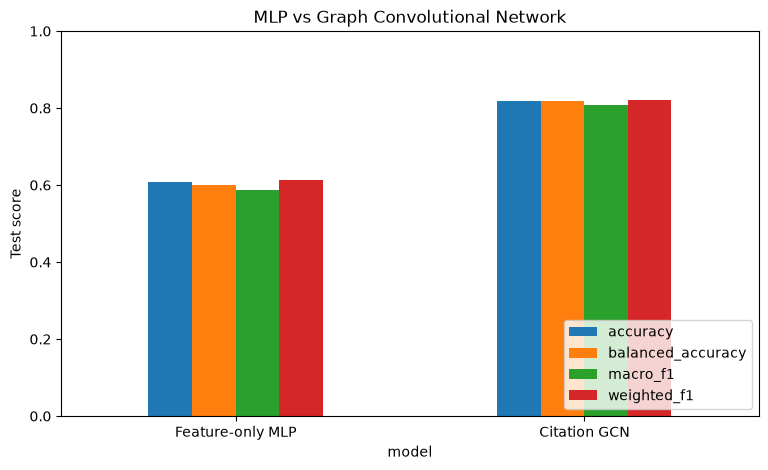

In [22]:
comparison_df.set_index("model")[
    [
        "accuracy",
        "balanced_accuracy",
        "macro_f1",
        "weighted_f1"
    ]
].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("MLP vs Graph Convolutional Network")
plt.ylabel("Test score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

## Model comparison 

The Citation GCN strongly outperformed the feature-only MLP.

| Model | Test accuracy | Balanced accuracy | Macro F1 | Weighted F1 |
|---|---:|---:|---:|---:|
| Feature-only MLP | 0.6090 | 0.6006 | 0.5869 | 0.6132 |
| Citation GCN | 0.8180 | 0.8174 | 0.8073 | 0.8197 |

Using the graph improved:

- Accuracy by 0.2090
- Macro F1-score by approximately 0.2204
- Balanced accuracy by approximately 0.2168

This is a substantial improvement rather than a small optimisation.

The result shows that citation relationships contain useful category information beyond the individual document features. Papers connected through citations often belong to related research areas, allowing the GCN to propagate informative signals across the graph.

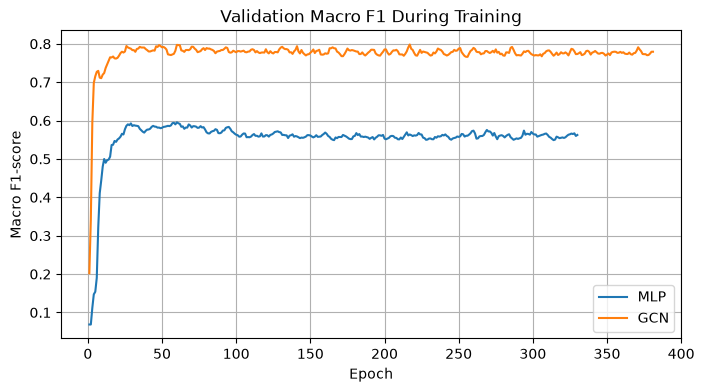

In [23]:
plt.figure(figsize=(8, 4))

plt.plot(
    mlp_history["epoch"],
    mlp_history["validation_macro_f1"],
    label="MLP"
)

plt.plot(
    gcn_history["epoch"],
    gcn_history["validation_macro_f1"],
    label="GCN"
)

plt.title("Validation Macro F1 During Training")
plt.xlabel("Epoch")
plt.ylabel("Macro F1-score")
plt.legend()
plt.grid(True)
plt.show()

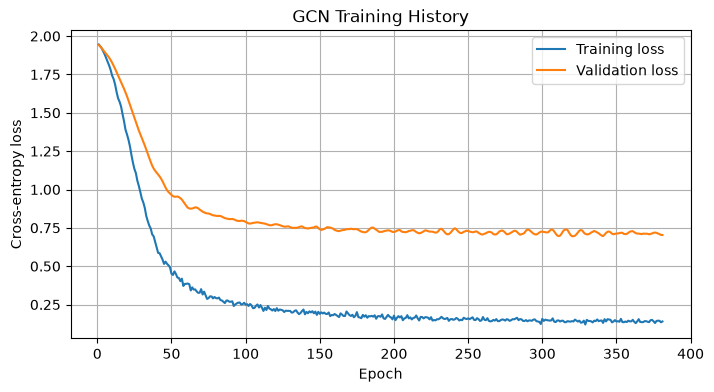

In [24]:
plt.figure(figsize=(8, 4))

plt.plot(
    gcn_history["epoch"],
    gcn_history["training_loss"],
    label="Training loss"
)

plt.plot(
    gcn_history["epoch"],
    gcn_history["validation_loss"],
    label="Validation loss"
)

plt.title("GCN Training History")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.legend()
plt.grid(True)
plt.show()

## Training behaviour 

The feature-only MLP stopped early at epoch 330, while the GCN stopped at epoch 381.

The GCN improved very quickly during the first part of training. Its validation macro F1-score rose to approximately 0.75 within the early epochs and later remained around 0.77 to 0.79.

The MLP improved initially but reached a much lower validation macro F1-score of approximately 0.59 before settling around 0.56 to 0.58.

For the GCN, training loss continued to decrease while validation loss levelled off at around 0.70. This indicates some overfitting after the early stages of training, which is expected because only 140 labelled training nodes were available.

Early stopping restored the model state with the best validation loss rather than simply keeping the final epoch.

In [25]:
gcn_model.eval()

with torch.no_grad():
    gcn_logits = gcn_model(
        data.x,
        data.edge_index
    )

    gcn_predictions = gcn_logits.argmax(
        dim=1
    )

test_true = data.y[
    data.test_mask
].cpu().numpy()

test_pred = gcn_predictions[
    data.test_mask
].cpu().numpy()

In [26]:
print(
    classification_report(
        test_true,
        test_pred,
        labels=list(range(dataset.num_classes)),
        target_names=[
            f"Class {i}"
            for i in range(dataset.num_classes)
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

     Class 0       0.67      0.76      0.71       130
     Class 1       0.79      0.85      0.82        91
     Class 2       0.88      0.87      0.87       144
     Class 3       0.89      0.82      0.85       319
     Class 4       0.82      0.85      0.83       149
     Class 5       0.86      0.76      0.80       103
     Class 6       0.70      0.83      0.76        64

    accuracy                           0.82      1000
   macro avg       0.80      0.82      0.81      1000
weighted avg       0.82      0.82      0.82      1000



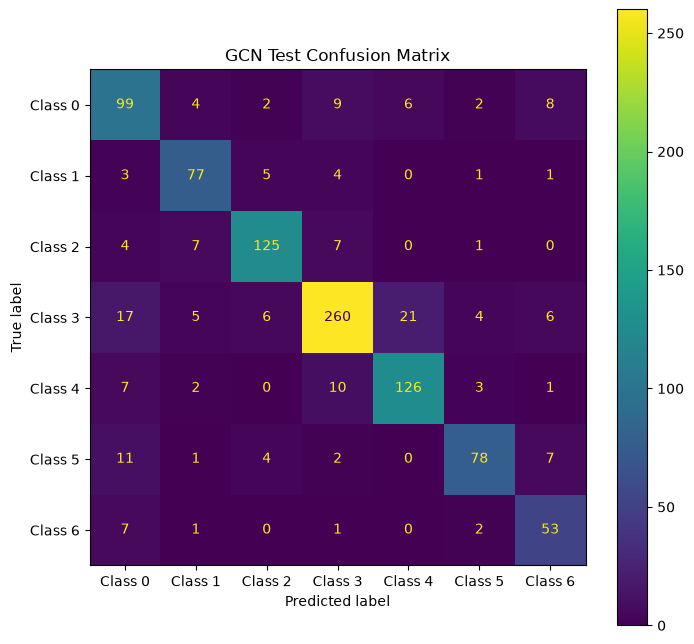

In [27]:
cm = confusion_matrix(
    test_true,
    test_pred,
    labels=list(range(dataset.num_classes))
)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        f"Class {i}"
        for i in range(dataset.num_classes)
    ]
)

fig, ax = plt.subplots(figsize=(8, 8))
display.plot(ax=ax)
plt.title("GCN Test Confusion Matrix")
plt.show()

## Class performance

The GCN achieved strong performance across all seven research categories.

| Class | Precision | Recall | F1-score | Test support |
|---|---:|---:|---:|---:|
| Class 0 | 0.67 | 0.76 | 0.71 | 130 |
| Class 1 | 0.79 | 0.85 | 0.82 | 91 |
| Class 2 | 0.88 | 0.87 | 0.87 | 144 |
| Class 3 | 0.89 | 0.82 | 0.85 | 319 |
| Class 4 | 0.82 | 0.85 | 0.83 | 149 |
| Class 5 | 0.86 | 0.76 | 0.80 | 103 |
| Class 6 | 0.70 | 0.83 | 0.76 | 64 |

Class 2 was the strongest class, with an F1-score of 0.87.

Class 0 was the weakest, with an F1-score of 0.71. Its relatively low precision indicates that papers from other categories were sometimes incorrectly assigned to Class 0.

The most common individual confusion was:

`Class 3 → Class 4`, with 21 cases.

Other notable confusions included:

- Class 3 → Class 0: 17 cases
- Class 5 → Class 0: 11 cases
- Class 4 → Class 3: 10 cases
- Class 0 → Class 3: 9 cases
- Class 0 → Class 6: 8 cases

The smallest class was not automatically the hardest. Class 6 had only 64 test examples but still achieved an F1-score of 0.76. Classification difficulty therefore depended on feature and neighbourhood overlap, not only class size.

In [28]:
empty_edge_index = torch.empty(
    (2, 0),
    dtype=torch.long,
    device=device
)

gcn_model.eval()

with torch.no_grad():
    normal_logits = gcn_model(
        data.x,
        data.edge_index
    )

    no_edge_logits = gcn_model(
        data.x,
        empty_edge_index
    )

normal_predictions = normal_logits.argmax(dim=1)
no_edge_predictions = no_edge_logits.argmax(dim=1)

In [29]:
def metrics_from_predictions(
    true_tensor,
    prediction_tensor,
    mask
):
    y_true = true_tensor[mask].cpu().numpy()
    y_pred = prediction_tensor[mask].cpu().numpy()

    return {
        "accuracy": accuracy_score(
            y_true,
            y_pred
        ),
        "macro_f1": f1_score(
            y_true,
            y_pred,
            average="macro"
        )
    }


edge_ablation_df = pd.DataFrame([
    {
        "setting": "Real citation graph",
        **metrics_from_predictions(
            data.y,
            normal_predictions,
            data.test_mask
        )
    },
    {
        "setting": "Citation edges removed",
        **metrics_from_predictions(
            data.y,
            no_edge_predictions,
            data.test_mask
        )
    }
])

edge_ablation_df

,setting,accuracy,macro_f1
0,Real citation graph,0.818,0.807269
1,Citation edges removed,0.710,0.687167


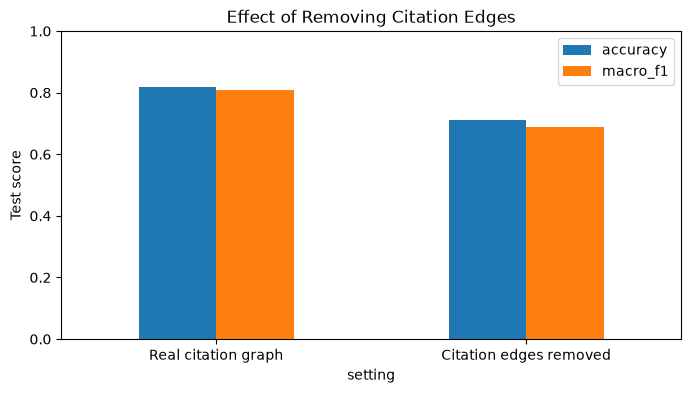

In [30]:
edge_ablation_df.set_index("setting")[
    ["accuracy", "macro_f1"]
].plot(
    kind="bar",
    figsize=(8, 4)
)

plt.title("Effect of Removing Citation Edges")
plt.ylabel("Test score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

## Edge ablation 

With the real citation graph, the GCN achieved:

- Accuracy: 0.8180
- Macro F1-score: 0.8073

When citation edges were removed at inference time, performance fell to:

- Accuracy: 0.7100
- Macro F1-score: 0.6872

Removing citation edges therefore caused:

- an accuracy decrease of 0.1080
- a macro F1 decrease of approximately 0.1201

The model still retained some predictive ability because it could use each paper's own features and automatically added self-connections.

However, the substantial decline confirms that the trained GCN relied meaningfully on information aggregated from neighbouring papers.

This was an inference-time stress test rather than a separately trained no-graph model, so it measures the effect of removing information the GCN expected to receive.

In [31]:
source = data.edge_index[0]
target = data.edge_index[1]

same_class_edge = (
    data.y[source] == data.y[target]
).float()

global_same_class_rate = same_class_edge.mean().item()

print(
    "Share of citation edges connecting the same class:",
    round(global_same_class_rate, 4)
)

Share of citation edges connecting the same class: 0.81


In [32]:
agreement_sum = torch.zeros(
    data.num_nodes,
    device=device
)

edge_count = torch.zeros(
    data.num_nodes,
    device=device
)

agreement_sum.scatter_add_(
    0,
    source,
    same_class_edge
)

edge_count.scatter_add_(
    0,
    source,
    torch.ones_like(same_class_edge)
)

neighbour_agreement = (
    agreement_sum
    / edge_count.clamp(min=1)
)

correct_predictions = (
    gcn_predictions == data.y
)

test_node_analysis = pd.DataFrame({
    "neighbour_label_agreement":
        neighbour_agreement[data.test_mask]
        .cpu()
        .numpy(),

    "correct_prediction":
        correct_predictions[data.test_mask]
        .cpu()
        .numpy(),

    "degree":
        edge_count[data.test_mask]
        .cpu()
        .numpy()
})

test_node_analysis.groupby(
    "correct_prediction"
)[
    ["neighbour_label_agreement", "degree"]
].agg(
    ["mean", "median", "count"]
)

neighbour_label_agreement                 degree         \
                                        mean median count      mean median   
correct_prediction                                                           
False                               0.515314    0.5   182  3.153846    2.0   
True                                0.883971    1.0   818  3.836186    3.0   

                          
                   count  
correct_prediction        
False                182  
True                 818

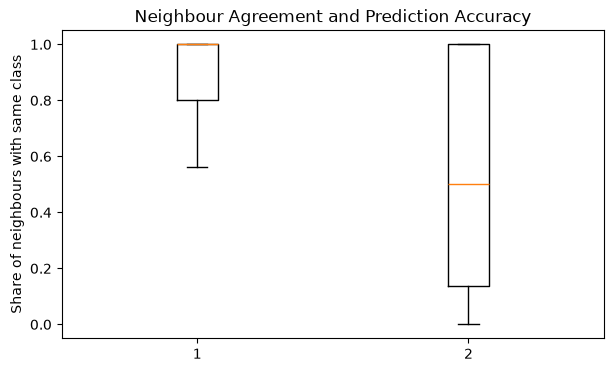

In [34]:
agreement_plot_data = [
    test_node_analysis.loc[
        test_node_analysis["correct_prediction"],
        "neighbour_label_agreement"
    ],

    test_node_analysis.loc[
        ~test_node_analysis["correct_prediction"],
        "neighbour_label_agreement"
    ]
]

plt.figure(figsize=(7, 4))
plt.boxplot(
    agreement_plot_data,
    label=["Correct", "Incorrect"],
    showfliers=False
)

plt.title("Neighbour Agreement and Prediction Accuracy")
plt.ylabel("Share of neighbours with same class")
plt.show()

## Graph structure insight

Approximately 81.00% of citation edges connected papers belonging to the same research class.

Correctly classified test nodes had:

- Mean neighbour-label agreement: 0.8840
- Median neighbour-label agreement: 1.0000
- Mean degree: 3.84
- Median degree: 3

Incorrectly classified test nodes had:

- Mean neighbour-label agreement: 0.5153
- Median neighbour-label agreement: 0.5000
- Mean degree: 3.15
- Median degree: 2

This is one of the strongest findings in the notebook.

Correctly classified papers were usually surrounded by neighbours from the same research category. Misclassified papers had much more mixed citation neighbourhoods.

The results suggest that GCN predictions are easier when the local network is homophilous, meaning neighbouring nodes commonly share the same label.

Papers connected across several research categories are harder to classify because neighbour aggregation can introduce conflicting category signals.

In [35]:
gcn_model.eval()

with torch.no_grad():
    _, node_embeddings = gcn_model(
        data.x,
        data.edge_index,
        return_embeddings=True
    )

embedding_array = (
    node_embeddings
    .cpu()
    .numpy()
)

In [36]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    init="pca",
    learning_rate="auto",
    random_state=RANDOM_STATE
)

embedding_2d = tsne.fit_transform(
    embedding_array
)

embedding_df = pd.DataFrame({
    "x": embedding_2d[:, 0],
    "y": embedding_2d[:, 1],
    "true_class": data.y.cpu().numpy(),
    "predicted_class":
        gcn_predictions.cpu().numpy()
})

embedding_df.head()

,x,y,true_class,predicted_class
0,49.116093,8.808999,3,3
1,25.595013,-48.164043,4,4
2,26.104296,-38.292648,4,4
3,-24.877155,-22.665649,0,0
4,32.186359,16.555351,3,3


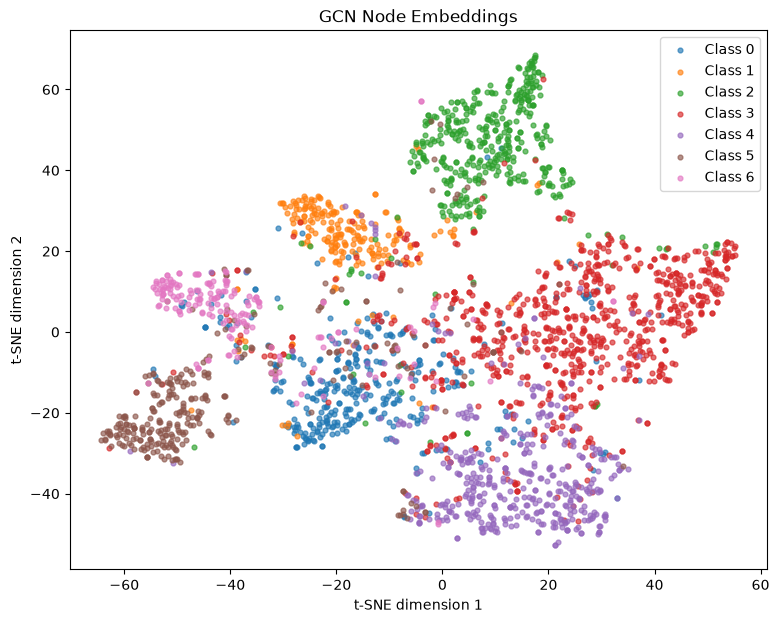

In [37]:
plt.figure(figsize=(9, 7))

for class_id in range(dataset.num_classes):
    class_rows = embedding_df[
        embedding_df["true_class"] == class_id
    ]

    plt.scatter(
        class_rows["x"],
        class_rows["y"],
        s=12,
        alpha=0.65,
        label=f"Class {class_id}"
    )

plt.title("GCN Node Embeddings")
plt.xlabel("t-SNE dimension 1")
plt.ylabel("t-SNE dimension 2")
plt.legend()
plt.show()

## Learned embeddings 

The t-SNE visualisation showed that the GCN learned meaningful category structure in its hidden node embeddings.

Several classes formed visibly distinct regions, especially Classes 1, 2, 4, 5, and 6.

Class 3 formed a large and relatively broad region, while Class 0 overlapped more heavily with several other categories. This overlap is consistent with Class 0 having the lowest test F1-score.

Some points from different classes appeared inside neighbouring clusters. These overlapping areas likely correspond to papers with mixed content, cross-category citations, or common model confusions.

The embeddings combine both the original paper features and information aggregated through citation links.

The t-SNE plot is useful for visual inspection, but distances and cluster shapes should be interpreted cautiously because t-SNE compresses a 64-dimensional embedding into only two dimensions.

In [38]:
final_summary = pd.DataFrame([
    {
        "experiment": "Feature-only MLP",
        "test_accuracy":
            mlp_test_metrics["accuracy"],
        "test_macro_f1":
            mlp_test_metrics["macro_f1"]
    },
    {
        "experiment": "Citation GCN",
        "test_accuracy":
            gcn_test_metrics["accuracy"],
        "test_macro_f1":
            gcn_test_metrics["macro_f1"]
    },
    {
        "experiment": "GCN without citation edges",
        "test_accuracy":
            edge_ablation_df.loc[
                edge_ablation_df["setting"]
                == "Citation edges removed",
                "accuracy"
            ].iloc[0],
        "test_macro_f1":
            edge_ablation_df.loc[
                edge_ablation_df["setting"]
                == "Citation edges removed",
                "macro_f1"
            ].iloc[0]
    }
])

final_summary

,experiment,test_accuracy,test_macro_f1
0,Feature-only MLP,0.609,0.586912
1,Citation GCN,0.818,0.807269
2,GCN without citation edges,0.710,0.687167
